<a href="https://colab.research.google.com/github/saraal1/IT326_Project/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Analysis

In [ ]:
import pandas as pd

# Load directly from your GitHub repository raw link
url = "https://raw.githubusercontent.com/saraal1/IT326_Project/main/Dataset/Raw_dataset.csv"
df = pd.read_csv(url)

## 1.1 Statistical summary

In [ ]:
# Display the statistical summary of numerical attributes
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


The statistical summary shows important information about the numerical features, including the mean, standard deviation, and range of values. It helps identify the distribution and variability of the data.

## 1.2 Five Number Summary

In [ ]:
# Select numerical attributes, excluding the target class
numeric_df = df.select_dtypes(include='number').drop(
    columns=['HeartDisease'], errors='ignore'
)

# Calculate the five-number summary
five_number_summary = numeric_df.describe().loc[
    ['min', '25%', '50%', '75%', 'max']
]

# Display the five-number summary
five_number_summary

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
min,28.0,0.0,0.00,0.0,60.0,-2.6
25%,47.0,120.0,173.25,0.0,120.0,0.0
50%,54.0,130.0,223.00,0.0,138.0,0.6
75%,60.0,140.0,267.00,0.0,156.0,1.5
max,77.0,200.0,603.00,1.0,202.0,6.2


The five number summary shows the minimum,first quartile (Q1), median (Q2), third quartile (Q3), and maximum values of each numerical attribute. It helps us understand the data distribution, measure its spread, and identify potential outliers.

## 1.3 Outliers Analysis

In [ ]:
# Calculate the first and third quartiles
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

# Calculate the interquartile range (IQR)
IQR = Q3 - Q1

# Identify potential outliers using the IQR method
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) |
            (numeric_df > (Q3 + 1.5 * IQR)))

# Count the potential outliers in each numerical attribute
outliers.sum()

,0
Age,0
RestingBP,28
Cholesterol,183
FastingBS,214
MaxHR,2
Oldpeak,16


The IQR method was used to identify potential outliers. Cholesterol and FastingBS showed the highest number of potential outliers, while Age had none. These values will be further examined using boxplots.

## 1.4 BoxPlots

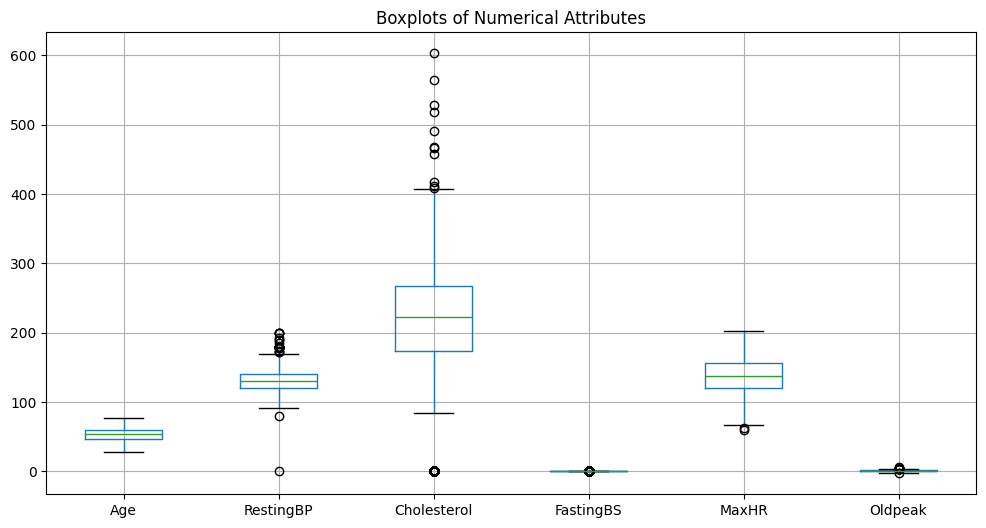

In [ ]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Create boxplots for numerical attributes
numeric_df.boxplot(figsize=(12, 6))

# Add a title to the plot
plt.title('Boxplots of Numerical Attributes')

# Display the plot
plt.show()

The boxplots show potential outliers in RestingBP, Cholesterol, MaxHR, and Oldpeak. Cholesterol has several extreme values, including zero values. FastingBS is a binary feature with values of 0 and 1. These values should be examined further during preprocessing.